In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
#from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.linear_model import Ridge, LogisticRegression, ridge_regression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score,balanced_accuracy_score
import plotly.express as px
from umap import UMAP
import seaborn as sns
sns.set_theme(style="ticks")

/volatile/ad279118/2023_jlaval_STSbabies/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Load the latent space from one model trained on UKB, on the right CINGULATE region

In [ ]:
#embeddings_UKB = pd.read_csv("/neurospin/dico/adufournet/Runs/01_Heritability_Right_PCS_HCP/Program/2024-04-24/10-50-27_36/UKB_epoch60_embeddings/full_embeddings.csv", index_col=0)
embeddings_UKB = pd.read_csv("/volatile/ad279118/Irene/MOSTEST/Results/ChampollionV0/SFint-FCMant_right/trained_on_UKB40/16-55-54_1/pheno_pre_residualized.txt", sep='\t')
if "#FID" in embeddings_UKB:
    embeddings_UKB  = embeddings_UKB.drop('#FID', axis=1)
if 'IID' in embeddings_UKB:
    embeddings_UKB = embeddings_UKB.rename(columns={'IID': 'ID'})
    embeddings_UKB.ID = embeddings_UKB.ID.apply(lambda x : f'sub-{x}')
    embeddings_UKB  = embeddings_UKB.set_index('ID')
embeddings_UKB.head()

#### Load the information about the ukb subjects (sex and age)

In [ ]:
ukb_info = pd.read_csv('/neurospin/dico/data/deep_folding/current/datasets/UkBioBank/participants_sex_age.csv')
ukb_info.head()

In [ ]:
ukb_volume = pd.read_csv('/volatile/ad279118/Runs/brain_segmentation_volume.csv',header=None, names=["ID", "Volume"])
ukb_volume

#### Merge the two dataframes on the participant ID

In [ ]:
ukb_fusion = embeddings_UKB.join(ukb_info.set_index('participant_id'), how='inner')
#ukb_fusion = ukb_fusion.join(ukb_volume.set_index('ID'), how='inner')
ukb_fusion

In [39]:
ukb_fusion.Sex.mean()

np.float64(0.47554098724964583)

In [ ]:
ukb_fusion[ukb_fusion['Volume']<8e5]

#### Scale the coordinates of all the representants

#### Choose the target (Sex)

In [ ]:
scaler = StandardScaler()
scaler.fit(ukb_fusion.drop(['Sex','Age','Volume'], axis=1))
scl_bdd_ukb = scaler.transform(ukb_fusion.drop(['Sex','Age', 'Volume'], axis=1))
y_sex = ukb_fusion['Sex']
y_sex

Set the model

In [11]:
model = LogisticRegression(max_iter=1000,
            random_state=42, class_weight='balanced')

#### Calculate the AUC and the balanced accuracy

In [12]:
outputs = {}
val_pred = cross_val_predict(model, scl_bdd_ukb, y_sex, cv=5)
auc = roc_auc_score(y_sex, val_pred)
outputs['labels_pred'] = val_pred
outputs['auc'] = auc
outputs['balanced_accuracy_score'] = balanced_accuracy_score(y_sex, val_pred)

In [13]:
outputs['auc'], outputs['balanced_accuracy_score']

(0.6074611927694117, 0.6074611927694116)

Let's see on a UMAP if it's easy to separate the males from the females

In [14]:
reducer = UMAP()#random_state=5)

reducer.fit(scl_bdd_ukb)
embedding2D_ukb = reducer.transform(scl_bdd_ukb)

bdd_2D_UKB = pd.DataFrame(embedding2D_ukb, columns=['Dim 1', 'Dim 2'])
bdd_2D_UKB['Dataset'] = 'UkBioBank'
bdd_2D_UKB['ID'] = ukb_fusion.index
bdd_2D_UKB = bdd_2D_UKB.join(ukb_fusion[["Sex","Age","Volume"]], on='ID')

<AxesSubplot:xlabel='Dim 1', ylabel='Dim 2'>

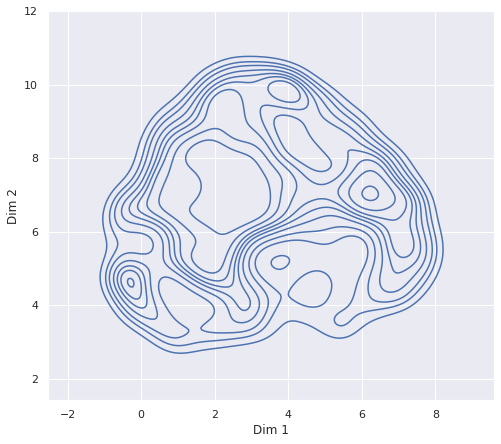

In [17]:
sns.set_theme(style="darkgrid")

# Set up the figure
f, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect("equal")

# Draw a contour plot to represent each bivariate density
sns.kdeplot(
    data=bdd_2D_UKB,
    x="Dim 1",
    y="Dim 2",
    thresh=.1,
)

In [68]:
fig = px.scatter(bdd_2D_UKB,
    x='Dim 1',
    y='Dim 2',
    color="Sex",
    labels={'color': 'Sex'},
    title='UMAP of the right CINGULATE region',
    template='plotly_white', 
    hover_data= ['Dataset', 'ID'],
    opacity=0.6,
    width=800, height=600
)

fig.update_traces(marker=dict(size=5))  # Adjust marker size

fig.show()

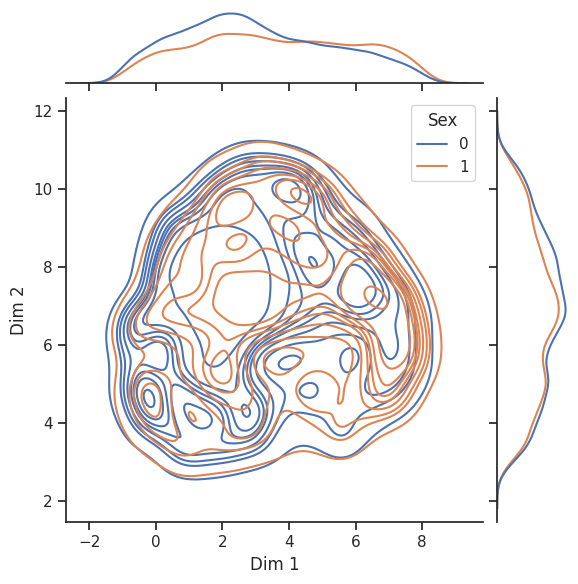

In [71]:
g = sns.jointplot(
    data=bdd_2D_UKB,
    x="Dim 1", y="Dim 2", hue="Sex",
    kind="kde"
)

#### Brain volume

In [23]:
fig = px.scatter(bdd_2D_UKB,
    x='Dim 1',
    y='Dim 2',
    color=ukb_fusion['Volume'].astype(float).to_numpy(),
    labels={'color': 'Volume'},
    title='UMAP of the right CINGULATE region',
    template='plotly_white', 
    hover_data= ['Dataset', 'ID'],
    opacity=0.6,
    width=800, height=600
)

fig.update_traces(marker=dict(size=5))  # Adjust marker size

fig.show()

In [91]:
# Calculate the 90th and 10th percentiles
top_10_threshold = bdd_2D_UKB['Volume'].quantile(0.90)
bottom_10_threshold = bdd_2D_UKB['Volume'].quantile(0.10)

# Define conditions based on the calculated thresholds
conditions = [
    (bdd_2D_UKB['Volume'] >= top_10_threshold),
    (bdd_2D_UKB['Volume'] <= bottom_10_threshold)
]

# Define choices corresponding to the conditions
choices = ['1', '0']

# Apply np.select to create the new column
bdd_2D_UKB['IS_BIG'] = np.select(conditions, choices, default='-1')

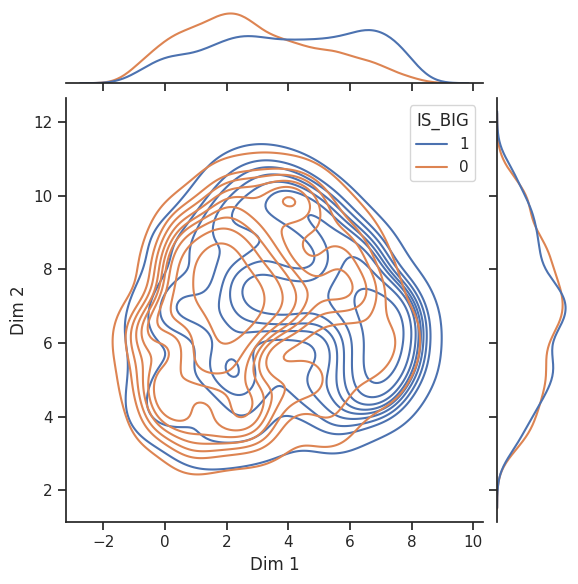

In [92]:
g = sns.jointplot(
    data=bdd_2D_UKB[bdd_2D_UKB['IS_BIG']!='-1'],
    x="Dim 1", y="Dim 2", hue="IS_BIG",
    kind="kde",
)

In [24]:
y_volume = ukb_fusion['Volume'].to_numpy()
print(y_volume)

X_train, X_test, y_train, y_test = train_test_split(scl_bdd_ukb, y_volume, test_size=0.33, random_state=42)

[1310943. 1377807. 1111215. ... 1117542.  991646. 1030743.]


In [25]:
ridge_model = Ridge(alpha=200)
ridge_model.fit(X_train, y_train)

Ridge(alpha=200)

In [26]:
ridge_model.score(X_train, y_train)

0.0820844898830051

In [27]:
ridge_model.score(X_test, y_test)

0.06784122598081743

In [28]:
ridge_model.predict(X_test)

array([1106976.15446271, 1145468.72125792, 1140136.72056767, ...,
       1134328.09216718, 1202813.1439019 , 1154229.13301139])

In [29]:
len(y_test), len(X_test)

(6472, 6472)

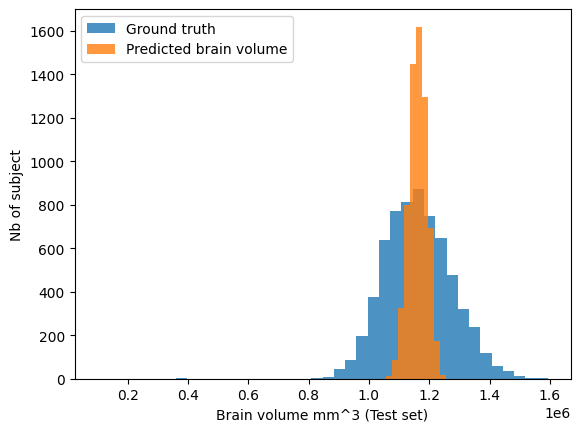

In [30]:
plt.hist(y_test, alpha=0.8, label='Ground truth', bins=40)
plt.hist(ridge_model.predict(X_test), alpha=0.8, label='Predicted brain volume', bins=10)
plt.xlabel('Brain volume mm^3 (Test set)')
plt.ylabel('Nb of subject')
plt.legend()
plt.show()

#### Ridge regression for the age

In [ ]:
y_age = ukb_fusion['Age']
print(y_age)

X_train, X_test, y_train, y_test = train_test_split(scl_bdd_ukb, y_age, test_size=0.33, random_state=42)

In [32]:
coef, intercept = ridge_regression(X_train, y_train, alpha=200, return_intercept=True)

The best possible score is 1.0 and it can be negative (because the model can be arbitrarily worse). A constant model that always predicts the expected value of y, disregarding the input features, would get a R² score of 0.0.

In [33]:
ridge_model = Ridge(alpha=200)
ridge_model.fit(X_train, y_train)

Ridge(alpha=200)

In [34]:
ridge_model.score(X_train, y_train)

0.02499108134560868

The model is a very bad predictor of the age.

In [35]:
ridge_model.score(X_test, y_test)

0.011678127158631368

Grid search cv to be sure that's not a model issue

In [36]:
ridge_model = Ridge()
param_grid = {'alpha': [0.1, 1, 10, 100, 200, 300, 400, 500]}
grid_search = GridSearchCV(estimator=ridge_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

In [37]:
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

Best parameters found:  {'alpha': 1}
Best cross-validation score:  -54.20290159077492


In [38]:
best_ridge_model = grid_search.best_estimator_
y_pred = best_ridge_model.predict(X_test)

In [39]:
best_ridge_model.score(X_train, y_train)

0.05579516241665261

In [40]:
best_ridge_model.score(X_test, y_test)

0.025460778109748117

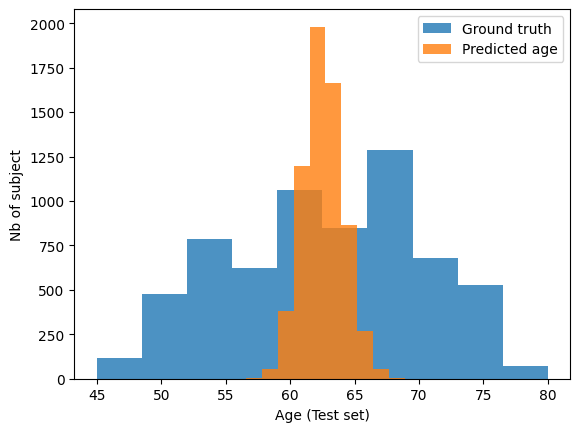

In [41]:
plt.hist(y_test, alpha=0.8, label='Ground truth')
plt.hist(best_ridge_model.predict(X_test), alpha=0.8, label='Predicted age')
plt.xlabel('Age (Test set)')
plt.ylabel('Nb of subject')
plt.legend()
plt.show()

In [60]:
mask = ukb_fusion[(ukb_fusion['Age']>76) | (ukb_fusion['Age']<48)].index

fig = px.scatter(bdd_2D_UKB[bdd_2D_UKB['ID'].isin(mask)],
    x='Dim 1',
    y='Dim 2',
    color=ukb_fusion.loc[mask]['Age'].to_numpy(),
    labels={'color': 'Age'},
    title='UMAP of the right CINGULATE region',
    template='plotly_white', 
    hover_data= ['Dataset', 'ID'],
    opacity=0.6,
    width=800, height=600
)

fig.update_traces(marker=dict(size=5))  # Adjust marker size

fig.show()